In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load the main transaction data
df = pd.read_csv('../data/raw/data.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nFirst 3 rows:")
df.head(3)

Dataset shape: (95662, 16)

Columns: ['TransactionId', 'BatchId', 'AccountId', 'SubscriptionId', 'CustomerId', 'CurrencyCode', 'CountryCode', 'ProviderId', 'ProductId', 'ProductCategory', 'ChannelId', 'Amount', 'Value', 'TransactionStartTime', 'PricingStrategy', 'FraudResult']

First 3 rows:


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0


In [2]:
print("=== DATA TYPES ===")
print(df.dtypes)

print("\n=== MISSING VALUES ===")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Count'] > 0])

print(f"\nTotal rows: {len(df):,}")
print(f"Total columns: {len(df.columns)}")
print(f"Duplicates: {df.duplicated().sum()}")

=== DATA TYPES ===
TransactionId            object
BatchId                  object
AccountId                object
SubscriptionId           object
CustomerId               object
CurrencyCode             object
CountryCode               int64
ProviderId               object
ProductId                object
ProductCategory          object
ChannelId                object
Amount                  float64
Value                     int64
TransactionStartTime     object
PricingStrategy           int64
FraudResult               int64
dtype: object

=== MISSING VALUES ===
Empty DataFrame
Columns: [Count, Percentage]
Index: []

Total rows: 95,662
Total columns: 16
Duplicates: 0


=== TRANSACTION AMOUNT STATISTICS ===
count    9.566200e+04
mean     6.717846e+03
std      1.233068e+05
min     -1.000000e+06
25%     -5.000000e+01
50%      1.000000e+03
75%      2.800000e+03
max      9.880000e+06
Name: Amount, dtype: float64


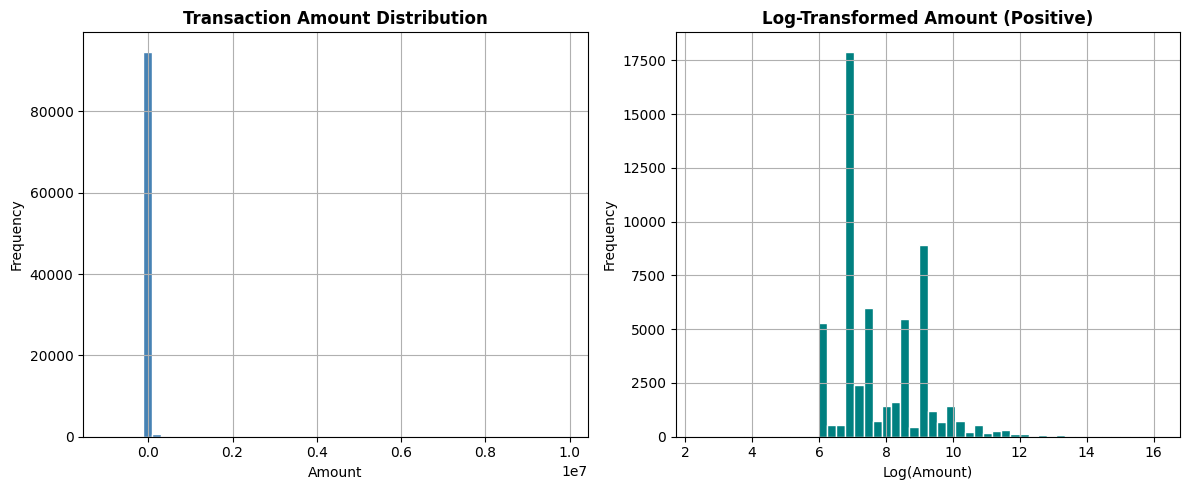

Chart saved!


In [3]:
print("=== TRANSACTION AMOUNT STATISTICS ===")
print(df['Amount'].describe())

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
df['Amount'].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Transaction Amount Distribution', fontweight='bold')
plt.xlabel('Amount')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
df[df['Amount'] > 0]['Amount'].apply(np.log1p).hist(bins=50, color='teal', edgecolor='white')
plt.title('Log-Transformed Amount (Positive)', fontweight='bold')
plt.xlabel('Log(Amount)')
plt.ylabel('Frequency')

plt.tight_layout()
plt.savefig('../reports/amount_distribution.png', dpi=150)
plt.show()
print("Chart saved!")

In [4]:
# Convert TransactionStartTime to datetime
df['TransactionStartTime'] = pd.to_datetime(df['TransactionStartTime'])

# Reference date = last transaction date in dataset
reference_date = df['TransactionStartTime'].max()

print(f"Reference date: {reference_date}")
print(f"Date range: {df['TransactionStartTime'].min()} to {reference_date}")

# Calculate RFM per customer
rfm = df.groupby('CustomerId').agg(
    Recency=('TransactionStartTime', lambda x: (reference_date - x.max()).days),
    Frequency=('TransactionId', 'count'),
    Monetary=('Amount', 'sum')
).reset_index()

print(f"\n=== RFM SUMMARY ===")
print(rfm.describe())

# Create risk label based on RFM
# High risk = high recency (hasn't bought recently) + low frequency + low monetary
rfm['Recency_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4,3,2,1]).astype(int)
rfm['Frequency_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)
rfm['Monetary_Score'] = pd.qcut(rfm['Monetary'].rank(method='first'), q=4, labels=[1,2,3,4]).astype(int)

rfm['RFM_Score'] = rfm['Recency_Score'] + rfm['Frequency_Score'] + rfm['Monetary_Score']

# Label: low RFM score = high risk
rfm['Risk_Label'] = (rfm['RFM_Score'] <= rfm['RFM_Score'].quantile(0.33)).astype(int)

print(f"\n=== RISK LABEL DISTRIBUTION ===")
print(f"High Risk (1): {rfm['Risk_Label'].sum():,} ({rfm['Risk_Label'].mean()*100:.1f}%)")
print(f"Low Risk (0):  {(rfm['Risk_Label']==0).sum():,} ({(1-rfm['Risk_Label'].mean())*100:.1f}%)")

Reference date: 2019-02-13 10:01:28+00:00
Date range: 2018-11-15 02:18:49+00:00 to 2019-02-13 10:01:28+00:00

=== RFM SUMMARY ===
           Recency    Frequency      Monetary
count  3742.000000  3742.000000  3.742000e+03
mean     30.461251    25.564404  1.717377e+05
std      27.118932    96.929602  2.717305e+06
min       0.000000     1.000000 -1.049000e+08
25%       5.000000     2.000000  4.077438e+03
50%      24.000000     7.000000  2.000000e+04
75%      53.000000    20.000000  7.996775e+04
max      90.000000  4091.000000  8.345124e+07

=== RISK LABEL DISTRIBUTION ===
High Risk (1): 1,508 (40.3%)
Low Risk (0):  2,234 (59.7%)


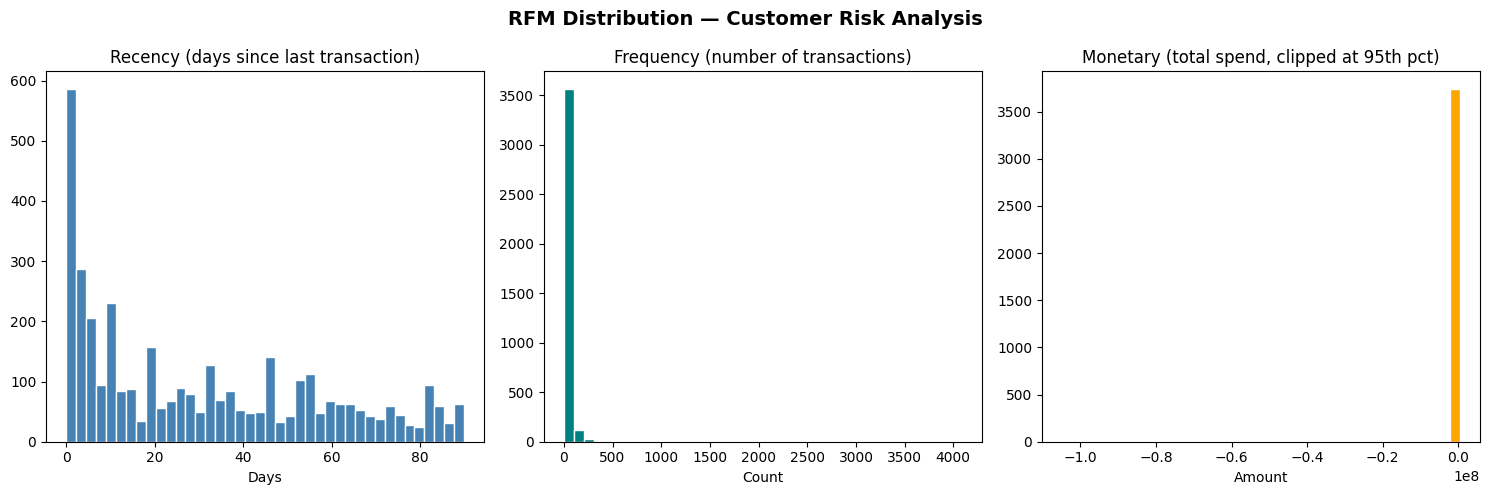

 Chart saved!


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('RFM Distribution — Customer Risk Analysis', fontsize=14, fontweight='bold')

axes[0].hist(rfm['Recency'], bins=40, color='steelblue', edgecolor='white')
axes[0].set_title('Recency (days since last transaction)')
axes[0].set_xlabel('Days')

axes[1].hist(rfm['Frequency'], bins=40, color='teal', edgecolor='white')
axes[1].set_title('Frequency (number of transactions)')
axes[1].set_xlabel('Count')

axes[2].hist(rfm['Monetary'].clip(upper=rfm['Monetary'].quantile(0.95)),
             bins=40, color='orange', edgecolor='white')
axes[2].set_title('Monetary (total spend, clipped at 95th pct)')
axes[2].set_xlabel('Amount')

plt.tight_layout()
plt.savefig('../reports/rfm_distribution.png', dpi=150)
plt.show()
print(" Chart saved!")

In [7]:
print("=" * 60)
print("KEY INSIGHTS — Credit Risk EDA")
print("=" * 60)

print(f"Dataset Overview:")
print(f"   Total transactions: {len(df):,}")
print(f"   Unique customers: {df['CustomerId'].nunique():,}")
print(f"   Date range: {df['TransactionStartTime'].min().date()} to {df['TransactionStartTime'].max().date()}")
print(f"   Unique products: {df['ProductId'].nunique():,}")

print(f"\nTransaction Analysis:")
print(f"   Average amount: {df['Amount'].mean():,.2f}")
print(f"   Total volume: {df['Amount'].sum():,.2f}")
print(f"   Negative amounts: {(df['Amount'] < 0).sum():,} (likely refunds/fees)")

print(f"\nFraud Analysis:")
print(f"   Fraud rate: {df['FraudResult'].mean()*100:.3f}%")
print(f"   Fraudulent transactions: {df['FraudResult'].sum():,}")

print(f"\nRFM Customer Segmentation:")
print(f"   Total customers analyzed: {len(rfm):,}")
print(f"   High-risk customers: {rfm['Risk_Label'].sum():,} ({rfm['Risk_Label'].mean()*100:.1f}%)")
print(f"   Avg recency (days): {rfm['Recency'].mean():.1f}")
print(f"   Avg transaction frequency: {rfm['Frequency'].mean():.1f}")

KEY INSIGHTS — Credit Risk EDA
Dataset Overview:
   Total transactions: 95,662
   Unique customers: 3,742
   Date range: 2018-11-15 to 2019-02-13
   Unique products: 23

Transaction Analysis:
   Average amount: 6,717.85
   Total volume: 642,642,625.50
   Negative amounts: 38,189 (likely refunds/fees)

Fraud Analysis:
   Fraud rate: 0.202%
   Fraudulent transactions: 193

RFM Customer Segmentation:
   Total customers analyzed: 3,742
   High-risk customers: 1,508 (40.3%)
   Avg recency (days): 30.5
   Avg transaction frequency: 25.6
